In [0]:
# Imports
# Uncomment the following line to install the required packages
!pip install pymupdf pandas matplotlib scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.3/24.3 MB 175.4 MB/s eta 0:00:00
Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


In [0]:
import fitz
import re
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

# PDF file paths
pdf_files = {
    # Path is based on root Workspace directory, please chance accordingly
    "NIST AI RMF 1.0": "/Workspace/Users/nalforque@sandiego.edu/nist.ai.100-1.pdf",
    "NIST GAI Profile": "/Workspace/Users/nalforque@sandiego.edu/NIST.AI.600-1.pdf",
    "EU AI Act": "/Workspace/Users/nalforque@sandiego.edu/OJ_L_202401689_EN_TXT.pdf"
}

# Extract text from PDFs
documents = []

for name, path in pdf_files.items():
    doc = fitz.open(path)
    pages = []
    
    for page_num, page in enumerate(doc, start=1):
        text = page.get_text()
        pages.append({
            "document": name,
            "page": page_num,
            "text": text
        })
    
    documents.extend(pages)
    doc.close()

df = pd.DataFrame(documents)

# Display the first few rows of the DataFrame
df.head()

,document,page,text
0,NIST AI RMF 1.0,1,NIST AI 100-1\nArtificial Intelligence Risk Ma...
1,NIST AI RMF 1.0,2,NIST AI 100-1\nArtificial Intelligence Risk Ma...
2,NIST AI RMF 1.0,3,"Certain commercial entities, equipment, or mat..."
3,NIST AI RMF 1.0,4,Table of Contents\nExecutive Summary\n1\nPart ...
4,NIST AI RMF 1.0,5,NIST AI 100-1\nAI RMF 1.0\nList of Figures\nFi...


In [0]:
def clean_words(text):
    return re.findall(r"[A-Za-z][A-Za-z\-']+", text.lower())

doc_stats = []

for name in df["document"].unique():
    full_text = " ".join(df[df["document"] == name]["text"])
    words = clean_words(full_text)
    
    doc_stats.append({
        "document": name,
        "pages": df[df["document"] == name]["page"].max(),
        "word_count": len(words),
        "unique_words": len(set(words)),
        "avg_words_per_page": round(len(words) / df[df["document"] == name]["page"].max(), 2)
    })

stats_df = pd.DataFrame(doc_stats)
stats_df

,document,pages,word_count,unique_words,avg_words_per_page
0,NIST AI RMF 1.0,48,15233,2308,317.35
1,NIST GAI Profile,64,21189,3091,331.08
2,EU AI Act,144,86799,3768,602.77


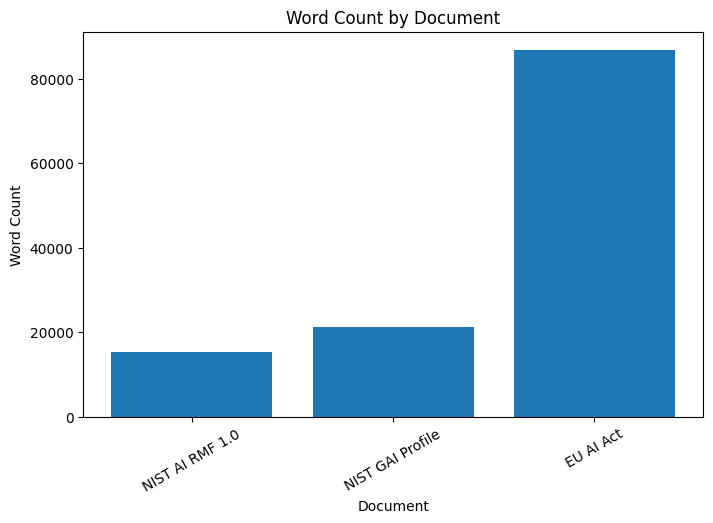

In [0]:
plt.figure(figsize=(8,5))
plt.bar(stats_df["document"], stats_df["word_count"])
plt.title("Word Count by Document")
plt.xlabel("Document")
plt.ylabel("Word Count")
plt.xticks(rotation=30)
plt.show()

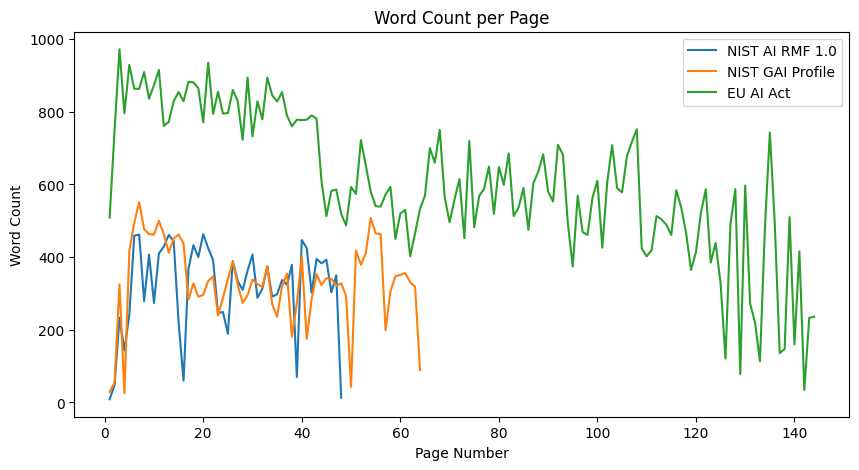

In [0]:
df["word_count"] = df["text"].apply(lambda x: len(clean_words(x)))

plt.figure(figsize=(10,5))

for name in df["document"].unique():
    subset = df[df["document"] == name]
    plt.plot(subset["page"], subset["word_count"], label=name)

plt.title("Word Count per Page")
plt.xlabel("Page Number")
plt.ylabel("Word Count")
plt.legend()
plt.show()

In [0]:
# Optimized stopwords list (expanded and deduplicated, tailored for regulatory/legal context)
stopwords = set("""
a an and are as at be by for from has have in is it its of on or that the to was were with 
this these those which into such may shall should can could would also not been being
article section chapter annex regulation european union nist ai rmf gai page table figure
but if so do does did will must might among between within without upon per each all any
more most some many every own same other another both either neither above below under
out up down over again further then once here there when where why how
""".split())

def get_top_words(text, n=20):
    words = clean_words(text)
    words = [w for w in words if w not in stopwords and len(w) > 2]
    return Counter(words).most_common(n)

for name in df["document"].unique():
    full_text = " ".join(df[df["document"] == name]["text"])
    print(f"\nTop words for {name}:")
    print(get_top_words(full_text, 20))


Top words for NIST AI RMF 1.0:
[('risk', 177), ('system', 172), ('systems', 161), ('risks', 155), ('management', 93), ('actors', 71), ('function', 68), ('map', 62), ('impacts', 55), ('organizations', 55), ('measure', 54), ('use', 54), ('framework', 51), ('govern', 51), ('manage', 51), ('data', 50), ('lifecycle', 47), ('their', 46), ('processes', 45), ('context', 44)]

Top words for NIST GAI Profile:
[('information', 246), ('content', 208), ('data', 207), ('risks', 206), ('system', 146), ('systems', 127), ('https', 108), ('use', 107), ('action', 107), ('risk', 102), ('models', 93), ('bias', 93), ('harmful', 90), ('integrity', 89), ('security', 86), ('model', 78), ('con', 76), ('ms-', 72), ('suggested', 71), ('training', 71)]

Top words for EU AI Act:
[('systems', 776), ('system', 704), ('data', 562), ('high-risk', 478), ('market', 377), ('their', 345), ('authorities', 332), ('law', 319), ('eli', 312), ('use', 301), ('including', 292), ('referred', 287), ('relevant', 283), ('provider', 

In [0]:
from collections import Counter
import pandas as pd
import matplotlib.pyplot as plt

top_word_rows = []

for name in df["document"].unique():
    full_text = " ".join(df[df["document"] == name]["text"])
    
    words = clean_words(full_text)
    words = [w for w in words if w not in stopwords and len(w) > 2]
    
    word_counts = Counter(words)
    top_20 = word_counts.most_common(20)
    
    for word, count in top_20:
        top_word_rows.append({
            "document": name,
            "word": word,
            "count": count
        })

top20_words_df = pd.DataFrame(top_word_rows)

top20_words_df

,document,word,count
0,NIST AI RMF 1.0,risk,177
1,NIST AI RMF 1.0,system,172
2,NIST AI RMF 1.0,systems,161
3,NIST AI RMF 1.0,risks,155
4,NIST AI RMF 1.0,management,93
5,NIST AI RMF 1.0,actors,71
6,NIST AI RMF 1.0,function,68
7,NIST AI RMF 1.0,map,62
8,NIST AI RMF 1.0,impacts,55
9,NIST AI RMF 1.0,organizations,55


These graphs show the top 20 most frequent words in each PDF after removing common stopwords. Separating the graphs by document makes the comparison easier to read because each PDF has its own vocabulary pattern. The NIST AI RMF emphasizes words such as risk, system, management, map, measure, govern, and manage. The NIST GAI Profile emphasizes information, content, data, risks, bias, harmful, integrity, and security. The EU AI Act emphasizes systems, data, high-risk, market, authorities, law, provider, and persons, showing its stronger legal and regulatory focus.

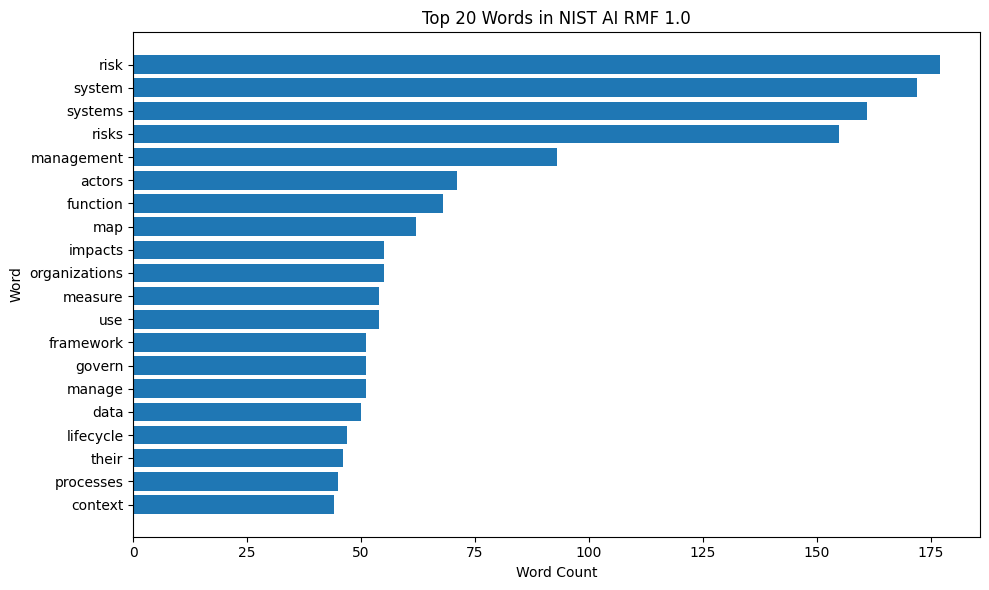

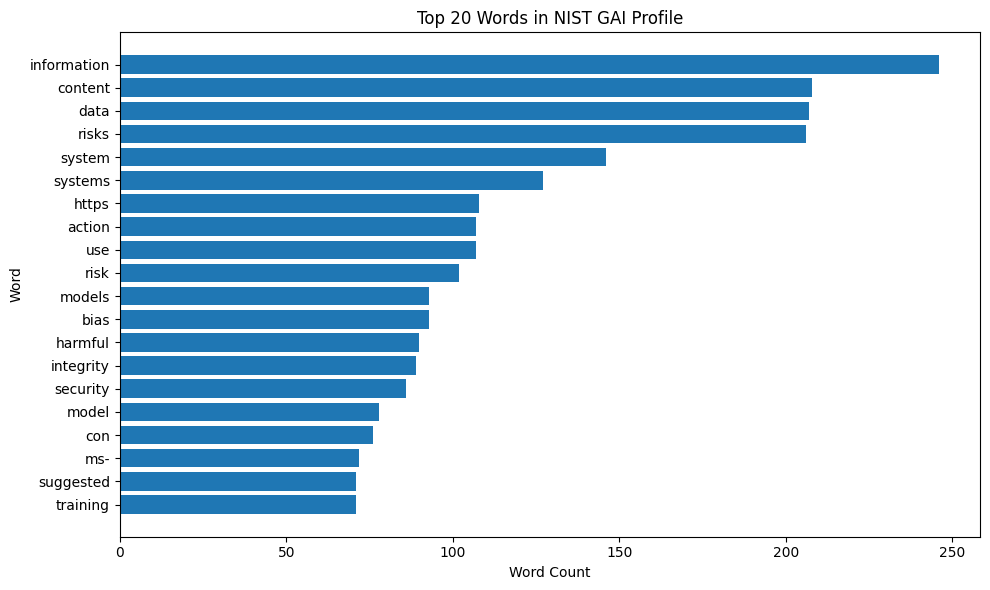

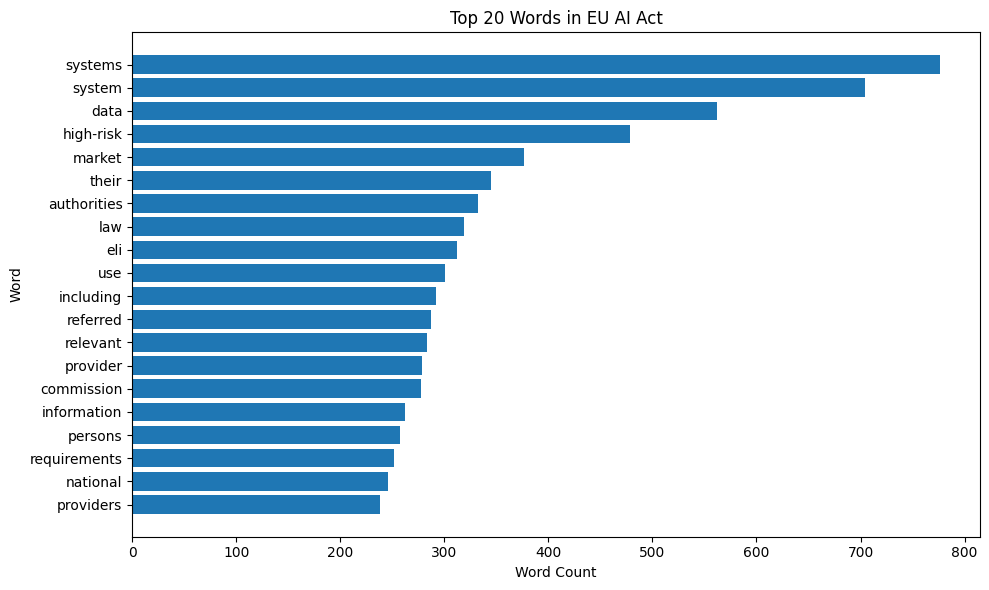

In [0]:
for name in top20_words_df["document"].unique():
    subset = top20_words_df[top20_words_df["document"] == name]
    subset = subset.sort_values("count", ascending=True)
    
    plt.figure(figsize=(10, 6))
    plt.barh(subset["word"], subset["count"])
    plt.title(f"Top 20 Words in {name}")
    plt.xlabel("Word Count")
    plt.ylabel("Word")
    plt.tight_layout()
    plt.show()

In [0]:
# Theme terms suggested and optimized by Genie AI 

theme_terms = {
    "risk_management": ["risk", "risks", "risk management", "mitigation", "manage"],
    "governance": ["governance", "govern", "policy", "policies", "oversight", "accountability"],
    "testing_evaluation": ["testing", "evaluation", "validation", "verification", "measure", "monitoring"],
    "privacy_data": ["privacy", "personal data", "data protection", "sensitive data", "biometric"],
    "security_safety": ["security", "safety", "secure", "resilient", "cybersecurity"],
    "bias_fairness": ["bias", "fairness", "fair", "discrimination", "homogenization"],
    "transparency": ["transparency", "transparent", "documentation", "record-keeping", "explainable"],
    "high_risk": ["high-risk", "high risk", "prohibited", "unacceptable"],
    "generative_ai": ["generative", "general-purpose", "foundation model", "synthetic content", "llm"]
}

theme_results = []

for name in df["document"].unique():
    full_text = " ".join(df[df["document"] == name]["text"]).lower()
    
    for theme, terms in theme_terms.items():
        count = 0
        
        for term in terms:
            count += full_text.count(term)
        
        theme_results.append({
            "document": name,
            "theme": theme,
            "count": count
        })

theme_df = pd.DataFrame(theme_results)
theme_df.head()

,document,theme,count
0,NIST AI RMF 1.0,risk_management,727
1,NIST AI RMF 1.0,governance,130
2,NIST AI RMF 1.0,testing_evaluation,147
3,NIST AI RMF 1.0,privacy_data,32
4,NIST AI RMF 1.0,security_safety,53


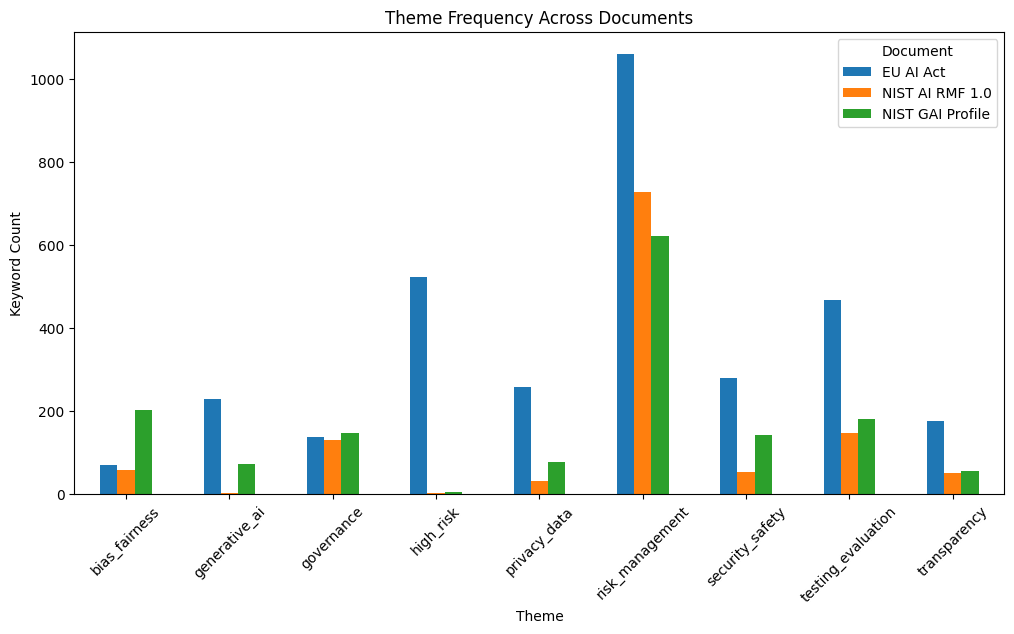

In [0]:
theme_pivot = theme_df.pivot(index="theme", columns="document", values="count")

theme_pivot.plot(kind="bar", figsize=(12,6))
plt.title("Theme Frequency Across Documents")
plt.xlabel("Theme")
plt.ylabel("Keyword Count")
plt.xticks(rotation=45)
plt.legend(title="Document")
plt.show()

In [0]:
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd
import matplotlib.pyplot as plt

bigram_rows = []

for name in df["document"].unique():
    full_text = " ".join(df[df["document"] == name]["text"]).lower()
    
    vectorizer = CountVectorizer(
        stop_words=list(stopwords),
        ngram_range=(2, 2),
        max_features=20
    )
    
    X = vectorizer.fit_transform([full_text])
    bigrams = vectorizer.get_feature_names_out()
    counts = X.toarray()[0]
    
    for bigram, count in zip(bigrams, counts):
        bigram_rows.append({
            "document": name,
            "bigram": bigram,
            "count": count
        })

bigram_df = pd.DataFrame(bigram_rows)
bigram_df.sort_values(["document", "count"], ascending=[True, False])

,document,bigram,count
50,EU AI Act,high risk,487
59,EU AI Act,risk systems,249
49,EU AI Act,general purpose,227
42,EU AI Act,2024 1689,186
58,EU AI Act,risk system,182
55,EU AI Act,parliament council,178
52,EU AI Act,market surveillance,175
53,EU AI Act,member states,158
44,EU AI Act,data europa,156
45,EU AI Act,eli http,156


### Bigram Analysis

The bigram analysis looks at the most common two-word phrases in each PDF. This gives more context than individual word counts because it shows which terms are commonly used together.

For the **NIST AI RMF 1.0**, the most frequent bigram is **risk management**, which fits the purpose of the document as a general framework for managing AI-related risks. Other common phrases such as **map function**, **govern function**, **measure function**, and **manage risks** also reflect the structure of the AI RMF framework. This shows that the document is focused on organizing AI risk management activities into clear functions and categories.

For the **NIST GAI Profile**, the top bigrams include **information integrity**, **harmful bias**, **information security**, **data privacy**, **content provenance**, and **intellectual property**. These phrases show that the document focuses more specifically on risks related to generative AI. The bigrams highlight concerns around misinformation, bias, privacy, security, harmful content, and the AI value chain.

For the **EU AI Act**, the most frequent bigram is **high risk**, which shows the regulation’s strong focus on classifying and controlling high-risk AI systems. Other common phrases such as **general purpose**, **market surveillance**, **member states**, **competent authorities**, and **risk systems** reflect the legal and regulatory nature of the document. Compared to the NIST documents, the EU AI Act uses more compliance-focused language related to obligations, authorities, and governance across the European Union.

Overall, the bigram results show that each PDF has a different focus. The NIST AI RMF emphasizes general AI risk management, the NIST GAI Profile emphasizes generative AI-specific risks, and the EU AI Act emphasizes legal compliance and high-risk AI regulation.


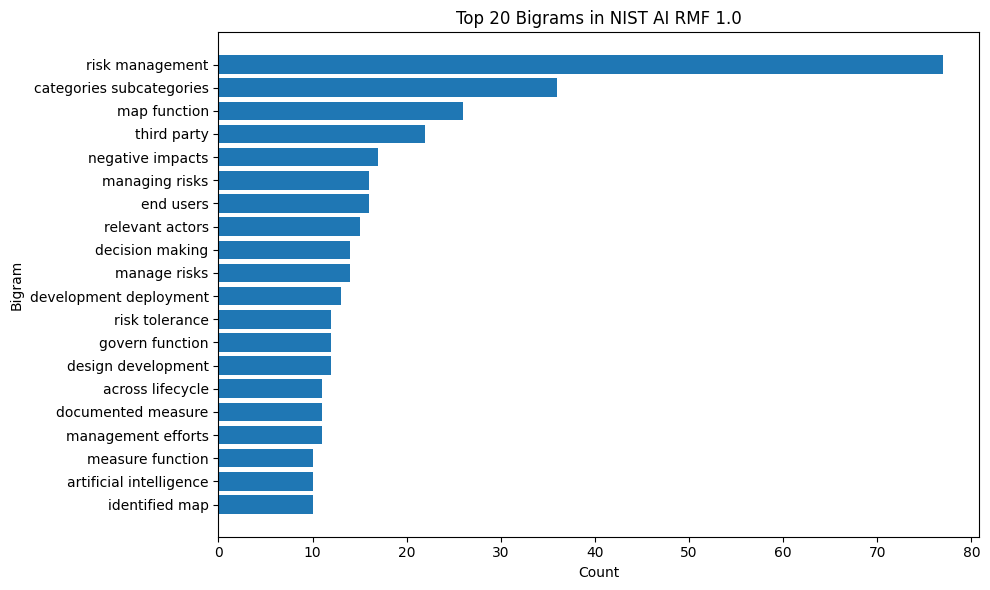

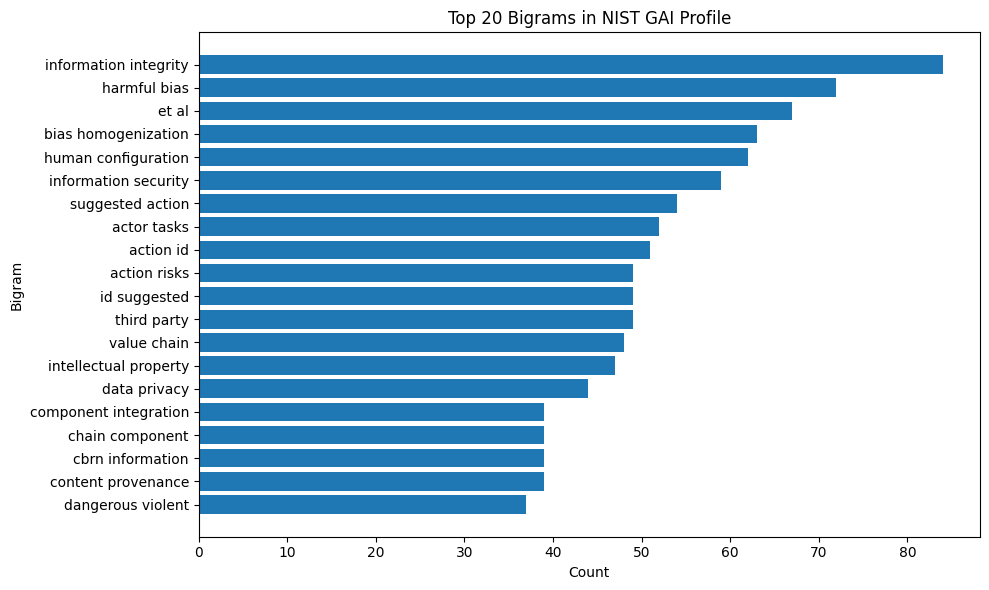

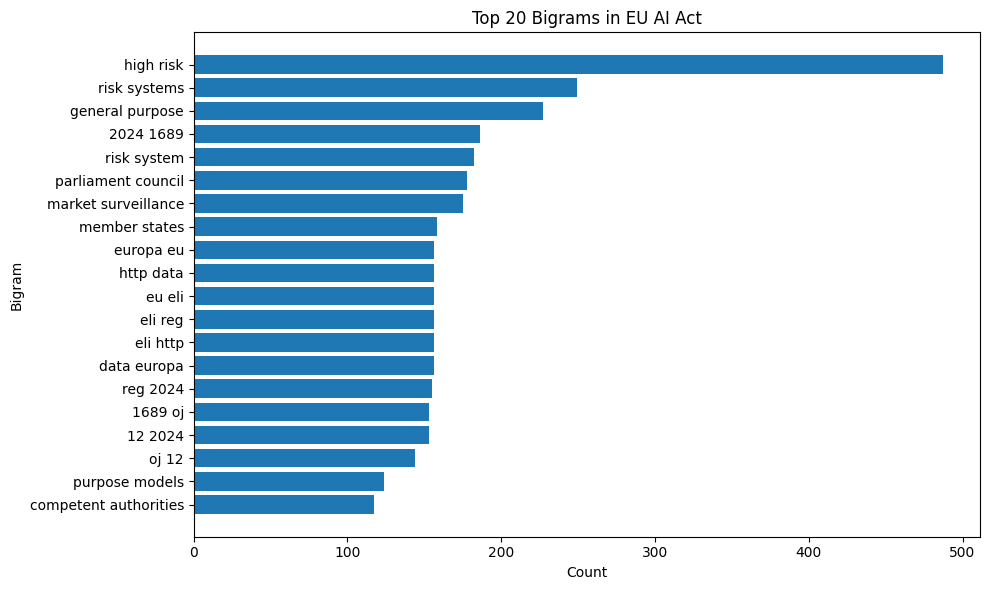

In [0]:
for name in bigram_df["document"].unique():
    subset = bigram_df[bigram_df["document"] == name].sort_values("count", ascending=True)
    
    plt.figure(figsize=(10, 6))
    plt.barh(subset["bigram"], subset["count"])
    plt.title(f"Top 20 Bigrams in {name}")
    plt.xlabel("Count")
    plt.ylabel("Bigram")
    plt.tight_layout()
    plt.show()

In [0]:
from sklearn.feature_extraction.text import TfidfVectorizer

doc_texts = []
doc_names = []

for name in df["document"].unique():
    full_text = " ".join(df[df["document"] == name]["text"]).lower()
    doc_texts.append(full_text)
    doc_names.append(name)

tfidf = TfidfVectorizer(
    stop_words=list(stopwords),
    max_features=1000,
    ngram_range=(1, 2)
)

X = tfidf.fit_transform(doc_texts)
terms = tfidf.get_feature_names_out()

tfidf_rows = []

for i, doc_name in enumerate(doc_names):
    scores = X[i].toarray()[0]
    top_indices = scores.argsort()[-20:][::-1]
    
    for idx in top_indices:
        tfidf_rows.append({
            "document": doc_name,
            "term": terms[idx],
            "tfidf_score": scores[idx]
        })

tfidf_df = pd.DataFrame(tfidf_rows)
tfidf_df

,document,term,tfidf_score
0,NIST AI RMF 1.0,risk,0.352019
1,NIST AI RMF 1.0,system,0.334612
2,NIST AI RMF 1.0,systems,0.311402
3,NIST AI RMF 1.0,risks,0.299797
4,NIST AI RMF 1.0,management,0.181812
5,NIST AI RMF 1.0,map,0.154417
6,NIST AI RMF 1.0,risk management,0.148931
7,NIST AI RMF 1.0,actors,0.137326
8,NIST AI RMF 1.0,organizations,0.136983
9,NIST AI RMF 1.0,function,0.133458


### TF-IDF Term Analysis

The TF-IDF analysis identifies terms that are important within each PDF, not just terms that appear frequently overall. This is useful because it helps highlight the vocabulary that best represents each document’s focus.

For the **NIST AI RMF 1.0**, the highest TF-IDF terms include **risk**, **system**, **systems**, **risks**, **management**, **map**, **risk management**, **actors**, **govern**, **measure**, and **manage**. These terms match the purpose of the document because the NIST AI RMF is centered on organizing AI risk management through the Govern, Map, Measure, and Manage functions. The results show that this PDF is mainly focused on broad AI risk management, system-level thinking, and organizational responsibilities.

For the **NIST GAI Profile**, the top TF-IDF terms include **information**, **content**, **data**, **risks**, **information integrity**, **homogenization**, **bias homogenization**, **human configuration**, and **configuration**. This shows that the document focuses more specifically on generative AI risks. The presence of terms related to information, content, bias, and human-AI configuration suggests that the GAI Profile emphasizes risks such as misinformation, harmful bias, data privacy, information security, and user interaction with generative AI systems.

For the **EU AI Act**, the top TF-IDF terms include **EU**, **systems**, **system**, **risk**, **data**, **high**, **market**, **high risk**, **persons**, **authorities**, **general purpose**, **commission**, and **law**. These terms reflect the legal and regulatory nature of the document. Compared to the NIST documents, the EU AI Act uses more language related to institutions, authorities, market rules, legal obligations, high-risk AI systems, and general-purpose AI models.

Overall, the TF-IDF results show that each document has a distinct role in the corpus. The NIST AI RMF provides the general risk management foundation, the NIST GAI Profile focuses on generative AI-specific risk areas, and the EU AI Act focuses on legal compliance and regulation. This supports the idea that the three PDFs work well together as a knowledge base for an AI governance and compliance assistant.


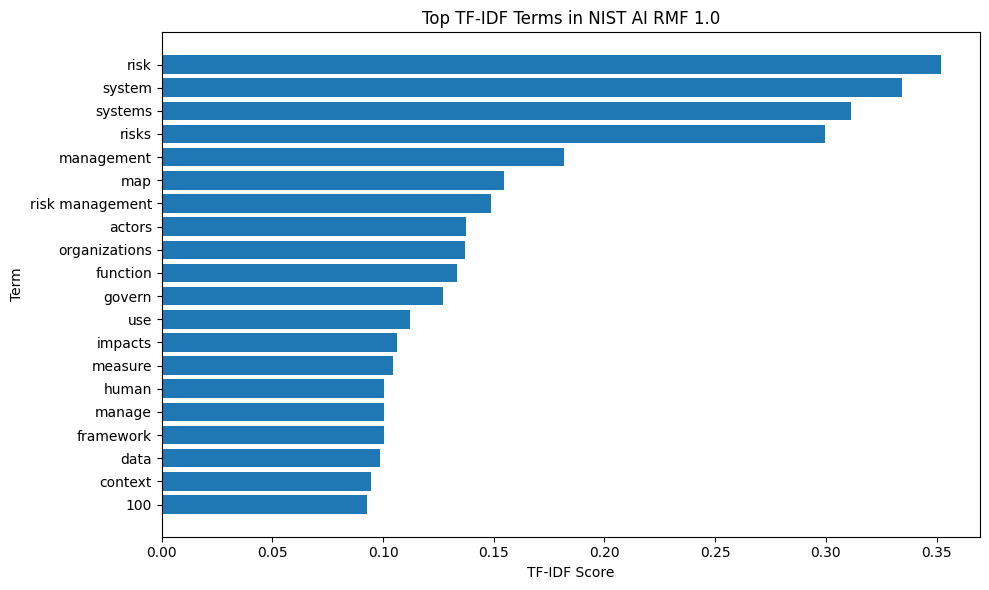

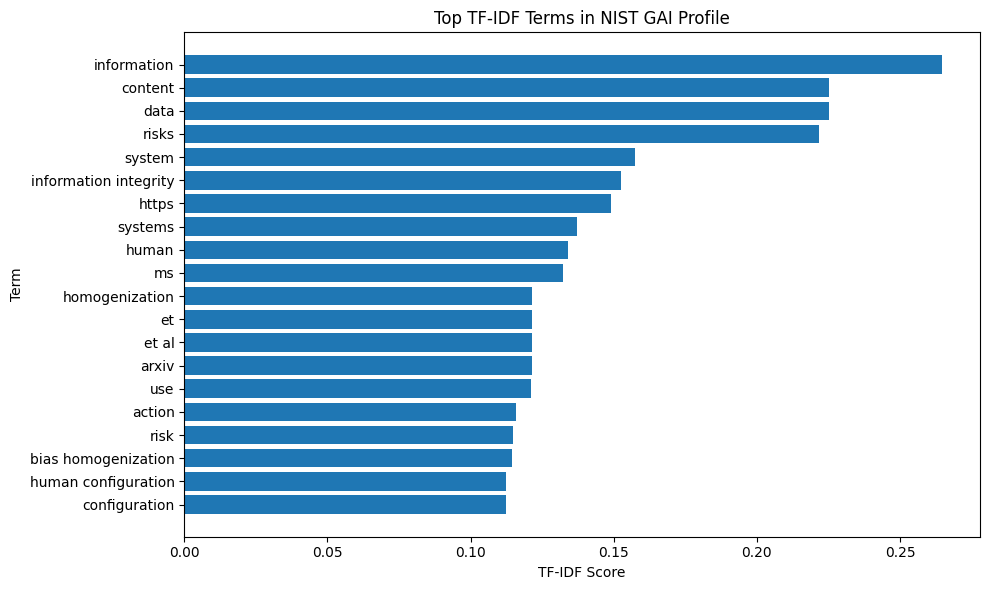

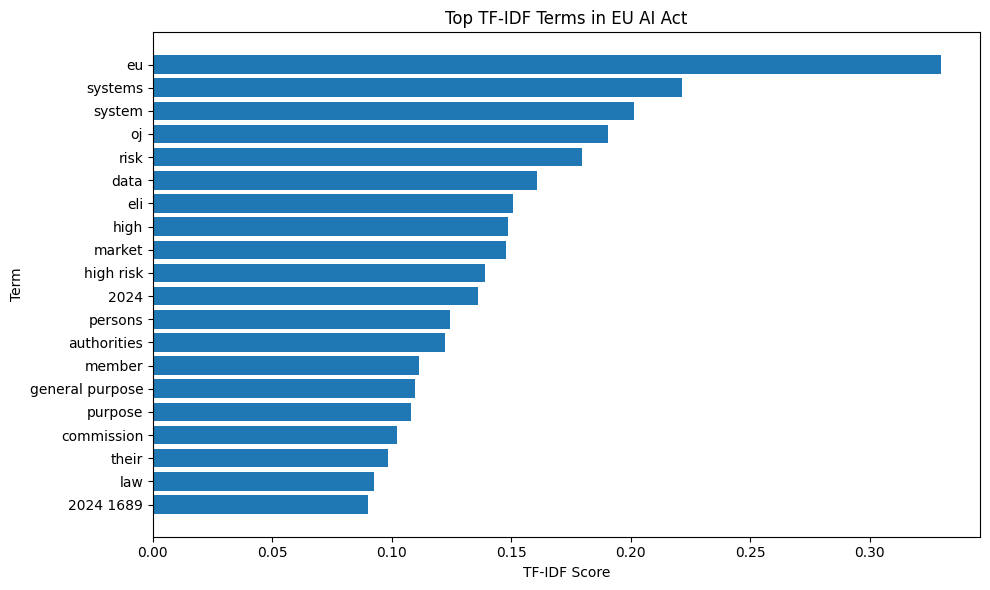

In [0]:
for name in tfidf_df["document"].unique():
    subset = tfidf_df[tfidf_df["document"] == name].sort_values("tfidf_score", ascending=True)
    
    plt.figure(figsize=(10, 6))
    plt.barh(subset["term"], subset["tfidf_score"])
    plt.title(f"Top TF-IDF Terms in {name}")
    plt.xlabel("TF-IDF Score")
    plt.ylabel("Term")
    plt.tight_layout()
    plt.show()

In [0]:
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    stop_words=list(stopwords),
    max_features=2000
)

X = vectorizer.fit_transform(doc_texts)
similarity_matrix = cosine_similarity(X)

similarity_df = pd.DataFrame(
    similarity_matrix,
    index=doc_names,
    columns=doc_names
)

similarity_df

,NIST AI RMF 1.0,NIST GAI Profile,EU AI Act
NIST AI RMF 1.0,1.000000,0.553190,0.416174
NIST GAI Profile,0.553190,1.000000,0.331418
EU AI Act,0.416174,0.331418,1.000000


### Document Similarity Analysis

The document similarity heatmap compares the three PDFs using TF-IDF and cosine similarity. A score closer to **1.0** means the documents use more similar vocabulary, while a score closer to **0** means they are less similar.

The **NIST AI RMF 1.0** and **NIST GAI Profile** have the highest similarity score at **0.55**. This makes sense because the GAI Profile is a companion document to the AI RMF and uses similar risk management language, including terms related to governance, risk, measurement, management, and trustworthiness.

The **NIST AI RMF 1.0** and **EU AI Act** have a moderate similarity score of **0.42**. This shows that they share some common AI governance and risk-related vocabulary, but the EU AI Act is more legal and regulatory in tone.

The **NIST GAI Profile** and **EU AI Act** have the lowest similarity score at **0.33**. Although both discuss AI risks, they focus on different areas. The NIST GAI Profile focuses more on generative AI-specific risks, while the EU AI Act focuses more on legal obligations, high-risk AI systems, providers, deployers, and compliance requirements.

Overall, the similarity results show that the two NIST documents are the most closely related, while the EU AI Act is more distinct because it is a formal regulation rather than a risk management framework.


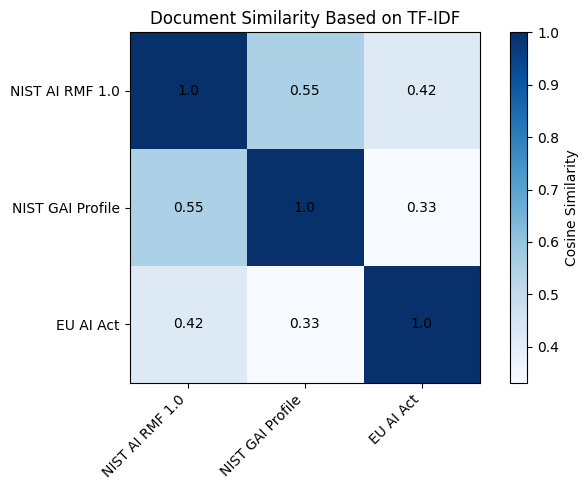

In [0]:
plt.figure(figsize=(7, 5))
plt.imshow(similarity_df, cmap="Blues")
plt.colorbar(label="Cosine Similarity")

plt.xticks(range(len(doc_names)), doc_names, rotation=45, ha="right")
plt.yticks(range(len(doc_names)), doc_names)

for i in range(len(doc_names)):
    for j in range(len(doc_names)):
        plt.text(j, i, round(similarity_df.iloc[i, j], 2),
                 ha="center", va="center")

plt.title("Document Similarity Based on TF-IDF")
plt.tight_layout()
plt.show()

In [0]:
page_theme_rows = []

for _, row in df.iterrows():
    text = row["text"].lower()
    
    for theme, terms in theme_terms.items():
        count = 0
        
        for term in terms:
            count += text.count(term)
            
        page_theme_rows.append({
            "document": row["document"],
            "page": row["page"],
            "theme": theme,
            "count": count
        })

page_theme_df = pd.DataFrame(page_theme_rows)
page_theme_df.head()

,document,page,theme,count
0,NIST AI RMF 1.0,1,risk_management,3
1,NIST AI RMF 1.0,1,governance,0
2,NIST AI RMF 1.0,1,testing_evaluation,0
3,NIST AI RMF 1.0,1,privacy_data,0
4,NIST AI RMF 1.0,1,security_safety,0


### Privacy and Data Mentions by Page

This section shows how often privacy and data-related terms appear across the pages of each PDF. The goal is to see where each document places emphasis on privacy, personal data, sensitive data, biometric data, and data protection.

For the **NIST AI RMF 1.0**, privacy and data mentions are spread out across the document, with the largest spike around page 22. This suggests that privacy is discussed as part of the broader AI risk management framework rather than being the main focus throughout the entire document. The smaller spikes later in the document show that privacy continues to appear in relation to governance, measurement, and trustworthy AI characteristics.

For the **NIST GAI Profile**, privacy and data mentions appear more frequently across the middle sections of the document, especially around pages 11, 30, and 34. This makes sense because generative AI introduces specific privacy risks, such as data leakage, unauthorized disclosure, sensitive data exposure, and risks from training or fine-tuning data. The pattern shows that privacy is treated as one of several major generative AI risk areas.

For the **EU AI Act**, privacy and data mentions are much more frequent and show larger spikes across the document. This is expected because the EU AI Act is a legal regulation that discusses personal data, biometric data, data protection, and compliance obligations in more detail. The early and middle page spikes suggest that privacy and data protection are important parts of the regulation’s explanation of AI risks, scope, obligations, and safeguards.

Overall, the page-level analysis shows that privacy and data are present in all three documents, but they are emphasized differently. The NIST AI RMF discusses privacy as part of trustworthy AI and general risk management. The NIST GAI Profile connects privacy to generative AI-specific risks. The EU AI Act discusses privacy and data protection more heavily from a legal and regulatory perspective.


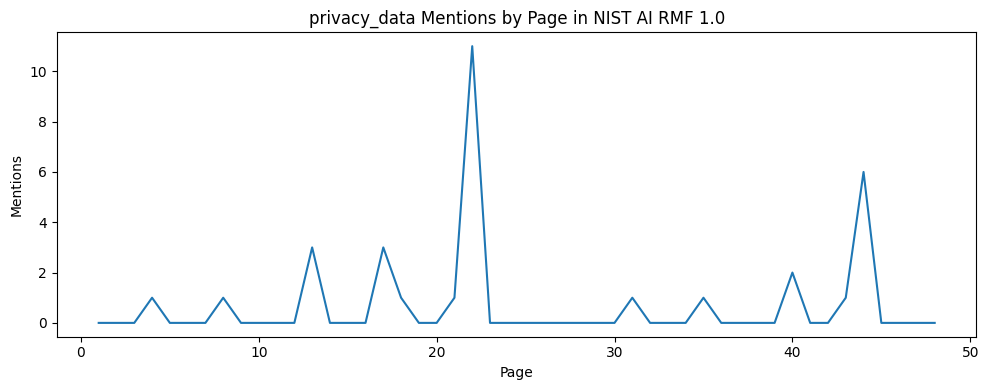

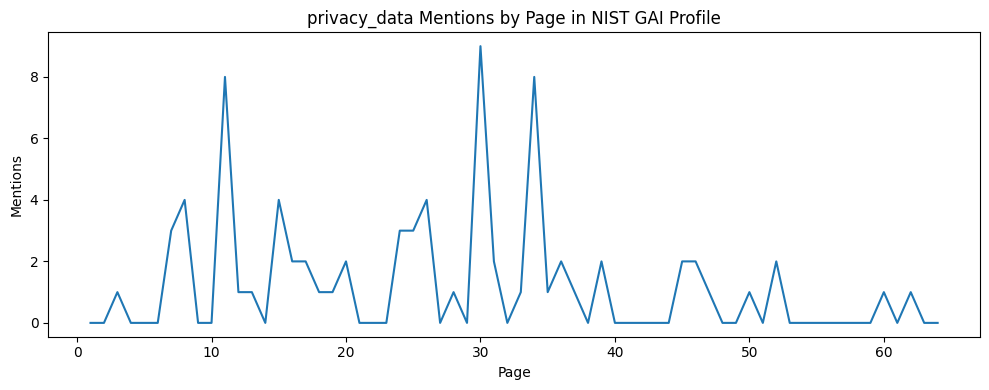

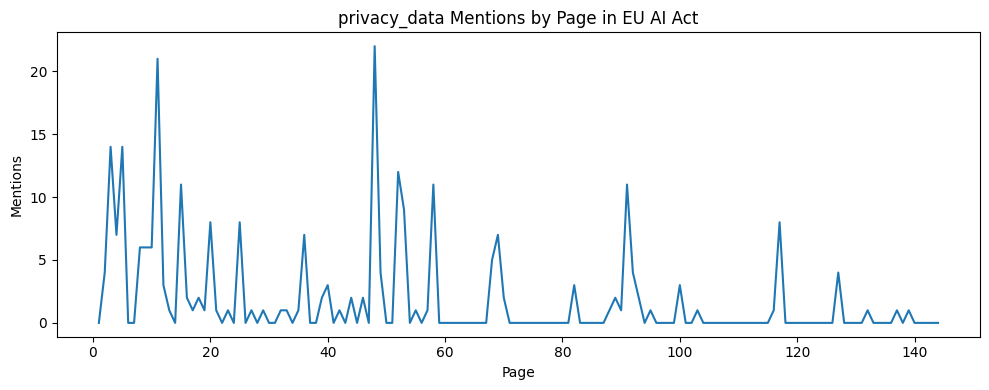

In [0]:
theme_to_plot = "privacy_data"

for name in page_theme_df["document"].unique():
    subset = page_theme_df[
        (page_theme_df["document"] == name) &
        (page_theme_df["theme"] == theme_to_plot)
    ]
    
    plt.figure(figsize=(10, 4))
    plt.plot(subset["page"], subset["count"])
    plt.title(f"{theme_to_plot} Mentions by Page in {name}")
    plt.xlabel("Page")
    plt.ylabel("Mentions")
    plt.tight_layout()
    plt.show()